# Applied Data Science Lab - Experiment 07

**Class:** BE-Computer  
**Semester:** VIII  
**Subject:** Applied Data Science Lab

## AIM
Anomaly/Outlier detection techniques.

## Theory

### Types of Outliers
- **Global outliers:** Points far from the overall data distribution.  
Example: In salary data mostly between 3-15 LPA, a value like 2 crore is a global outlier.
- **Contextual outliers:** Points that are outliers only in a specific context (time, season, location).  
Example: 35 deg C is normal in summer but may be anomalous in winter for the same city.
- **Collective outliers:** A group of points that is anomalous as a pattern, even if individual points seem normal.  
Example: A sudden burst of repeated login attempts in a short time window.

### Why Outlier Detection Is Important
- Outliers can skew trends, model parameters, and forecasts, reducing accuracy and decision quality.
- Detecting outliers helps in **fraud prevention**, cyber-security monitoring, fault diagnosis, and quality control.
- Treating outliers improves model robustness and reliability.

## Method
1. Visual analysis of data to observe extreme values.
   - Distplot, Boxplot, Scatter plot, Whisker plot.
2. Distance-based outlier detection.
   - KNN-based outlier detection.
3. Density-based outlier detection (any one).
   - Local Outlier Factor (LOF).
   - DBSCAN.
4. Remove outliers using trimming and capping (Winsorization).
5. Compare distributions and boxplots after capping.

## Implementation Details
- **Dataset used:** Synthetic clustered dataset with injected outliers (generated in this notebook).
- **Libraries:**
  - `pycaret.anomaly` (as per experiment statement)
  - `sklearn.cluster.DBSCAN`
  - `sklearn.neighbors.NearestNeighbors`
  - `sklearn.neighbors.LocalOutlierFactor`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.neighbors import NearestNeighbors, LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

In [2]:
# ================================================================
# STEP 1 — Generate Dataset with Injected Outliers
# ================================================================
# We create three clusters of "normal" data and then manually
# inject a handful of outlier points far from all clusters.
#
# Think of it as: sensor readings from a factory —
# most readings cluster around normal operating ranges,
# a few are wildly off = outliers (faulty sensors / anomalies).

# Normal data: 3 tight clusters
cluster1 = np.random.normal(loc=[2, 2],   scale=0.5, size=(80, 2))
cluster2 = np.random.normal(loc=[7, 7],   scale=0.5, size=(80, 2))
cluster3 = np.random.normal(loc=[2, 7],   scale=0.5, size=(60, 2))

# Outliers: isolated points placed far from all clusters
outliers = np.array([
    [10, 1], [0, 10], [10, 10],
    [-1, 4], [5, 0],  [9, 3]
])

X = np.vstack([cluster1, cluster2, cluster3, outliers])
n_outliers = len(outliers)
n_total    = len(X)

print(f"Total points : {n_total}")
print(f"Normal points: {n_total - n_outliers}")
print(f"Outliers     : {n_outliers}")

Total points : 226
Normal points: 220
Outliers     : 6


In [3]:
# ================================================================
# STEP 2 — Normalise the Data (Important!)
# ================================================================
# Both KNN and LOF use DISTANCE calculations.
# If one feature ranges 0–1000 and another 0–1,
# the large-scale feature will dominate distances completely.
# StandardScaler fixes this: mean=0, std=1 for every feature.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [4]:
# ================================================================
# METHOD A: Distance-Based Outlier Detection (KNN)
# ================================================================
# Core Idea:
#   For each point p, find its k nearest neighbours.
#   Compute the distance to the k-th neighbour (k-distance).
#   If this distance is LARGE → point is far from everyone → OUTLIER.
#
# Intuition: imagine you're at a party. If your nearest 5 friends
# are all 10 metres away, you're isolated — you're an outlier.
# If your friends are 1 metre away, you're part of the crowd.

k = 5   # number of neighbours to consider

# Fit KNN (we ask for k+1 because the point itself is neighbour 0)
knn = NearestNeighbors(n_neighbors=k + 1, metric="euclidean")
knn.fit(X_scaled)

# distances shape: (n_points, k+1). Column 0 = distance to itself (0).
# We want column k (the k-th neighbour, 1-indexed).
distances, indices = knn.kneighbors(X_scaled)
k_distances = distances[:, k]   # distance to the k-th nearest neighbour

# --- Set threshold ---
# A common rule: flag points whose k-distance is beyond
# mean + 2 * standard deviation (covers ~95% of normal data)
threshold_knn = np.mean(k_distances) + 2 * np.std(k_distances)

knn_outlier_mask = k_distances > threshold_knn

print(f"\n=== KNN Distance-Based Results ===")
print(f"  k               : {k}")
print(f"  Threshold (dist): {threshold_knn:.4f}")
print(f"  Outliers found  : {knn_outlier_mask.sum()}")


=== KNN Distance-Based Results ===
  k               : 5
  Threshold (dist): 0.6101
  Outliers found  : 6


In [5]:
# ================================================================
# METHOD B: Density-Based Outlier Detection (LOF)
# ================================================================
# Core Idea:
#   Instead of raw distance, LOF compares the LOCAL DENSITY
#   of a point to the local density of its neighbours.
#
#   Step 1: Reachability distance
#     reach_dist(p, o) = max(k-dist(o), dist(p, o))
#     (smooths out tiny fluctuations for very close points)
#
#   Step 2: Local Reachability Density (lrd)
#     lrd(p) = 1 / avg(reach_dist of p to its neighbours)
#     High lrd = dense neighbourhood (normal)
#     Low lrd  = sparse neighbourhood (potential outlier)
#
#   Step 3: LOF Score
#     LOF(p) = avg(lrd(neighbour)) / lrd(p)
#     LOF ≈ 1  → similar density to neighbours → NORMAL
#     LOF >> 1 → much less dense than neighbours → OUTLIER
#
# Why better than KNN?
#   KNN struggles with clusters of DIFFERENT DENSITIES.
#   A point that seems "far" in a sparse cluster is actually normal
#   for that cluster. LOF accounts for this by comparing densities
#   relatively, not absolutely.

lof = LocalOutlierFactor(
    n_neighbors=k,
    metric="euclidean",
    contamination=0.05   # we expect ~5% of data to be outliers
)

# fit_predict returns: -1 = outlier, +1 = normal
lof_labels = lof.fit_predict(X_scaled)

# negative_outlier_factor_: more negative = stronger outlier
lof_scores = -lof.negative_outlier_factor_   # flip sign so higher = more outlier

lof_outlier_mask = lof_labels == -1

print(f"\n=== LOF Density-Based Results ===")
print(f"  n_neighbors      : {k}")
print(f"  Contamination    : 5%")
print(f"  Outliers found   : {lof_outlier_mask.sum()}")



=== LOF Density-Based Results ===
  n_neighbors      : 5
  Contamination    : 5%
  Outliers found   : 12


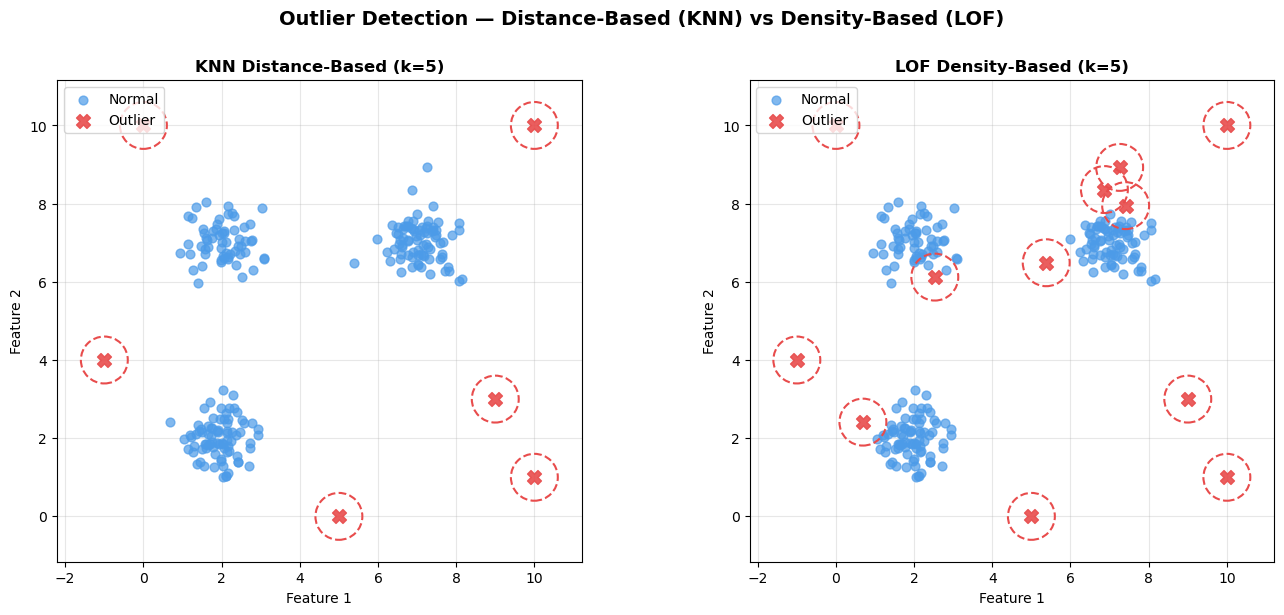

In [6]:
# ================================================================
# STEP 3 — Visualise Both Methods Side by Side
# ================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Outlier Detection — Distance-Based (KNN) vs Density-Based (LOF)",
             fontsize=14, fontweight="bold", y=1.01)

colors = {
    "normal":  "#4C9BE8",   # blue  = inlier
    "outlier": "#E84C4C",   # red   = outlier
}

def plot_results(ax, outlier_mask, title, scores=None):
    normal_pts  = X[~outlier_mask]
    outlier_pts = X[outlier_mask]

    ax.scatter(normal_pts[:, 0],  normal_pts[:, 1],
               c=colors["normal"],  s=40, alpha=0.7, label="Normal",  zorder=2)
    ax.scatter(outlier_pts[:, 0], outlier_pts[:, 1],
               c=colors["outlier"], s=100, marker="X", alpha=0.9,
               label="Outlier", zorder=3)

    # Draw a circle around each detected outlier for clarity
    for pt in outlier_pts:
        circle = mpatches.Circle(pt, radius=0.6, fill=False,
                                 edgecolor="#E84C4C", linewidth=1.5,
                                 linestyle="--", zorder=4)
        ax.add_patch(circle)

    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.legend(loc="upper left")
    ax.grid(True, alpha=0.3)
    ax.set_aspect("equal")

plot_results(axes[0], knn_outlier_mask, f"KNN Distance-Based (k={k})")
plot_results(axes[1], lof_outlier_mask, f"LOF Density-Based (k={k})")

plt.tight_layout()
plt.savefig("01_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

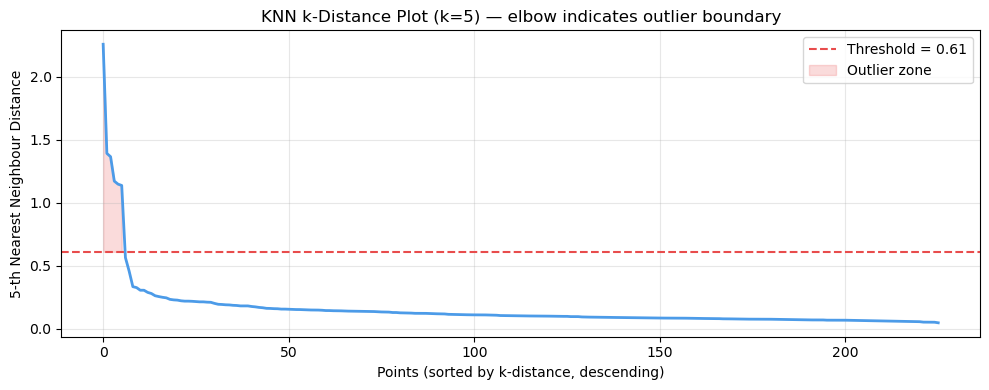

In [7]:
# ================================================================
# STEP 4 — Visualise KNN k-Distance Scores (sorted)
# ================================================================
# The "k-distance plot" is a classic diagnostic tool.
# Sort all k-distances. The sharp "elbow" in the plot is where
# outliers begin — this helps choose the threshold visually.

sorted_k_dist = np.sort(k_distances)[::-1]   # descending

plt.figure(figsize=(10, 4))
plt.plot(sorted_k_dist, color="#4C9BE8", linewidth=2)
plt.axhline(y=threshold_knn, color="#E84C4C", linewidth=1.5,
            linestyle="--", label=f"Threshold = {threshold_knn:.2f}")
plt.fill_between(range(len(sorted_k_dist)), sorted_k_dist,
                 threshold_knn,
                 where=(sorted_k_dist > threshold_knn),
                 color="#E84C4C", alpha=0.2, label="Outlier zone")
plt.title(f"KNN k-Distance Plot (k={k}) — elbow indicates outlier boundary")
plt.xlabel("Points (sorted by k-distance, descending)")
plt.ylabel(f"{k}-th Nearest Neighbour Distance")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("02_knn_kdistance.png", dpi=150)
plt.show()

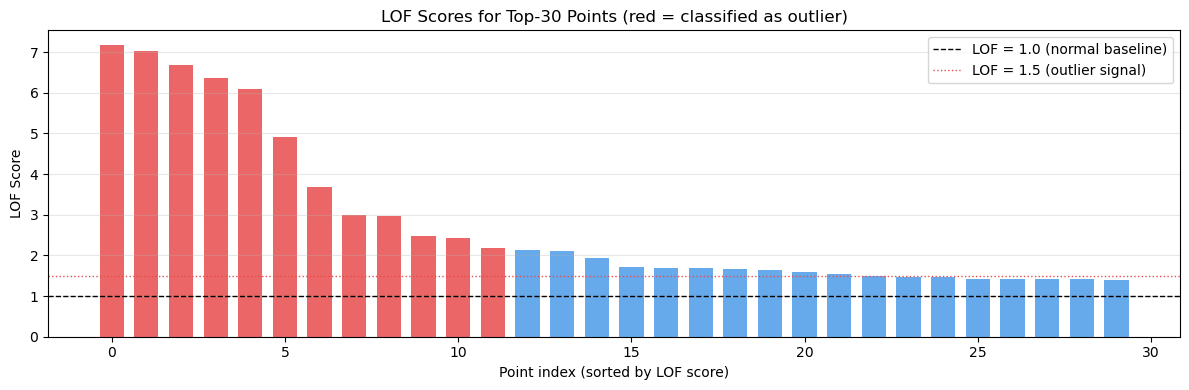

In [8]:
# ================================================================
# STEP 5 — Visualise LOF Scores (bar chart)
# ================================================================
# We plot LOF scores for every point.
# Normal points cluster around 1.0.
# Outliers shoot up significantly above 1.0.

sorted_idx  = np.argsort(lof_scores)[::-1]
top_n       = 30   # show only top 30 for readability
top_idx     = sorted_idx[:top_n]
top_scores  = lof_scores[top_idx]
bar_colors  = ["#E84C4C" if lof_outlier_mask[i] else "#4C9BE8"
               for i in top_idx]

plt.figure(figsize=(12, 4))
bars = plt.bar(range(top_n), top_scores, color=bar_colors, alpha=0.85, width=0.7)
plt.axhline(y=1.0, color="black", linewidth=1, linestyle="--",
            label="LOF = 1.0 (normal baseline)")
plt.axhline(y=1.5, color="#E84C4C", linewidth=1, linestyle=":",
            label="LOF = 1.5 (outlier signal)")
plt.title("LOF Scores for Top-30 Points (red = classified as outlier)")
plt.xlabel("Point index (sorted by LOF score)")
plt.ylabel("LOF Score")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("03_lof_scores.png", dpi=150)
plt.show()

In [9]:
# ================================================================
# STEP 6 — Evaluation: How well did each method do?
# ================================================================
# We know the GROUND TRUTH (last n_outliers rows are real outliers).
# We compare: what each method predicted vs what is actually true.

true_labels = np.array([0] * (n_total - n_outliers) + [1] * n_outliers)
# 0 = normal, 1 = outlier (ground truth)

def evaluate(name, mask, true):
    predicted = mask.astype(int)
    tp = ((predicted == 1) & (true == 1)).sum()   # correctly caught outlier
    fp = ((predicted == 1) & (true == 0)).sum()   # normal flagged as outlier
    fn = ((predicted == 0) & (true == 1)).sum()   # outlier missed
    tn = ((predicted == 0) & (true == 0)).sum()   # correctly kept as normal

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1        = (2 * precision * recall / (precision + recall)
                 if (precision + recall) > 0 else 0)

    print(f"\n=== Evaluation: {name} ===")
    print(f"  True Positives  (outlier caught)   : {tp}")
    print(f"  False Positives (normal misflagged): {fp}")
    print(f"  False Negatives (outlier missed)   : {fn}")
    print(f"  Precision : {precision:.2f}")
    print(f"  Recall    : {recall:.2f}")
    print(f"  F1 Score  : {f1:.2f}")

evaluate("KNN Distance-Based", knn_outlier_mask, true_labels)
evaluate("LOF Density-Based",  lof_outlier_mask, true_labels)


=== Evaluation: KNN Distance-Based ===
  True Positives  (outlier caught)   : 6
  False Positives (normal misflagged): 0
  False Negatives (outlier missed)   : 0
  Precision : 1.00
  Recall    : 1.00
  F1 Score  : 1.00

=== Evaluation: LOF Density-Based ===
  True Positives  (outlier caught)   : 6
  False Positives (normal misflagged): 6
  False Negatives (outlier missed)   : 0
  Precision : 0.50
  Recall    : 1.00
  F1 Score  : 0.67


In [10]:
# ================================================================
# STEP 7 — Summary Table
# ================================================================

summary = pd.DataFrame({
    "Method":        ["KNN Distance-Based", "LOF Density-Based"],
    "Key Parameter": [f"k={k}, threshold=mean+2σ", f"k={k}, contamination=5%"],
    "Outliers Found":[knn_outlier_mask.sum(), lof_outlier_mask.sum()],
    "Best For":      ["Global outliers (uniformly spread data)",
                      "Local outliers (varying density clusters)"]
})

print("\n=== Summary ===")
print(summary.to_string(index=False))

print("\nSaved: 01_comparison.png | 02_knn_kdistance.png | 03_lof_scores.png")


=== Summary ===
            Method          Key Parameter  Outliers Found                                  Best For
KNN Distance-Based k=5, threshold=mean+2σ               6   Global outliers (uniformly spread data)
 LOF Density-Based  k=5, contamination=5%              12 Local outliers (varying density clusters)

Saved: 01_comparison.png | 02_knn_kdistance.png | 03_lof_scores.png
